In [ ]:
import joblib
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

from ml_baselines.modelling.train import train_baseline_model, train_baseline_model_grid_search
from ml_baselines.config import Config

In [2]:
cfg = Config()
site = "MHD"

MLP model

Training mlp model for site: MHD
... balancing dataset to target baseline ratio of 0.5
Number of training points: 6322
... number of baseline points: 3161 (50.0%)
... fitting
... predicting
Precision on Training Set = 0.793
Precision on Validation Set = 0.445
Precision on Test Set = 0.541
Recall on Training Set = 0.537
Recall on Validation Set = 0.551
Recall on Test Set = 0.583
F1 Score on Training Set = 0.641
F1 Score on Validation Set = 0.493
F1 Score on Test Set = 0.561


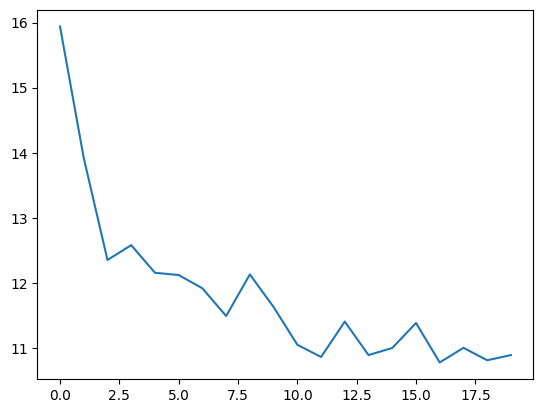

In [ ]:
# manual train
mlp_params_dict = {'activation': 'relu',
               'alpha': 0.0001,
               'batch_size': 10,
               'early_stopping': True,
               'hidden_layer_sizes': (50,),
               'learning_rate': "constant",
               'learning_rate_init': 0.0001,
               'shuffle': False,
               'max_iter': 1000,
               'solver': 'adam'}

model, X, y = train_baseline_model("MHD",
                                model_type="mlp",
                                balance=0.5,
                                balance_method='random',
                                undersample=0,
                                sample_weights=None,
                                time_shift_hours=[24, 72],
                                prediction_threshold=0.5,
                                model_params=mlp_params_dict,
                                return_scores=False,
                                verbose=True
                                )

plt.plot(model.loss_curve_)

In [15]:
# run a grid search
grid_search = train_baseline_model_grid_search("MHD",
                                        model_type="mlp",
                                        scoring="precision",
                                        param_grid={'activation': ['relu'],
                                                'alpha': [0.0001],
                                                'batch_size': [5, 10],
                                                'early_stopping': [True],
                                                'hidden_layer_sizes': [(50,)],
                                                'learning_rate': ["constant"],
                                                'learning_rate_init': [0.0001],
                                                'shuffle': [False],
                                                'max_iter': [1000],
                                                'solver': ['adam']},
                                        data_kwargs={'time_shift_hours': [[24, 72],
                                                                        [24],
                                                                        [6]]},
                                        validation_keys=["time_shift_hours"],
                                        )

... data kwargs: {'time_shift_hours': [24, 72]}
Training MLP model for site: MHD with grid search...
Fitting 1 folds for each of 2 candidates, totalling 2 fits
Best parameters found:  {'activation': 'relu', 'alpha': 0.0001, 'batch_size': 5, 'early_stopping': True, 'hidden_layer_sizes': (50,), 'learning_rate': 'constant', 'learning_rate_init': 0.0001, 'max_iter': 1000, 'shuffle': False, 'solver': 'adam'}
Best score:  0.5232308791994281
... data kwargs: {'time_shift_hours': [24]}
Training MLP model for site: MHD with grid search...
Fitting 1 folds for each of 2 candidates, totalling 2 fits
Best parameters found:  {'activation': 'relu', 'alpha': 0.0001, 'batch_size': 5, 'early_stopping': True, 'hidden_layer_sizes': (50,), 'learning_rate': 'constant', 'learning_rate_init': 0.0001, 'max_iter': 1000, 'shuffle': False, 'solver': 'adam'}
Best score:  0.5420447670901392
... data kwargs: {'time_shift_hours': [6]}
Training MLP model for site: MHD with grid search...
Fitting 1 folds for each of 2 

In [ ]:
# Save model
# met_str = f"-{cfg.met_type}" if cfg.met_type else ""
# joblib.dump(model, Path(cfg.models_path) / f"mlp{met_str}_{site}.joblib")

Random forest model

In [ ]:
# manual train
random_forest_params_dict = {'n_estimators':200,
               'criterion': 'entropy',
               'max_depth': 5,
               'min_samples_split': 2,
               'min_samples_leaf': 1,
               'max_features': None,
               'bootstrap': True,
               'max_samples': None
               }

model, X, y = train_baseline_model("MHD",
                                model_type="random_forest",
                                balance=0.5,
                                balance_method='random',
                                undersample=0,
                                sample_weights=None,
                                time_shift_hours=[24, 72],
                                prediction_threshold=0.5,
                                model_params=random_forest_params_dict,
                                return_scores=False,
                                verbose=True
                                )

Training random_forest model for site: MHD
... balancing dataset to target baseline ratio of 0.5
Number of training points: 6322
... number of baseline points: 3161 (50.0%)
... fitting
... predicting
Precision on Training Set = 0.792
Precision on Validation Set = 0.379
Precision on Test Set = 0.472
Recall on Training Set = 0.924
Recall on Validation Set = 0.846
Recall on Test Set = 0.838
F1 Score on Training Set = 0.853
F1 Score on Validation Set = 0.523
F1 Score on Test Set = 0.604


In [4]:
# run a grid search
grid_search = train_baseline_model_grid_search("MHD",
                                        model_type="random_forest",
                                        scoring="precision",
                                        param_grid = {
                                                'n_estimators': [100, 200,],
                                                'criterion': ['gini', 'entropy',],
                                                'max_depth': [None, 5, 10,],
                                                'min_samples_split': [2, 5,],
                                                'max_features': ['log2', 'sqrt',],
                                                'bootstrap': [True, False],
                                        },
                                        data_kwargs={'time_shift_hours': [[24, 72],
                                                                        [24],
                                                                        [6]]},
                                        validation_keys=["time_shift_hours"],
                                        )

... data kwargs: {'time_shift_hours': [24, 72]}
Training random_forest model for site: MHD with grid search...
Fitting 1 folds for each of 96 candidates, totalling 96 fits


KeyboardInterrupt: 

In [ ]:
# Save model
# met_str = f"-{cfg.met_type}" if cfg.met_type else ""
# joblib.dump(model, Path(cfg.models_path) / f"random_forest{met_str}_{site}.joblib")

Gradient boosted model

In [17]:
# manual train
gradient_boosting_params_dict = {'loss': 'log_loss',
                   'learning_rate': 0.05,
                   'n_estimators': 200,
                   'criterion': 'friedman_mse',
                   'min_samples_split': 10,
                   'min_samples_leaf': 5,
                   'max_depth': 3,
                   'max_features': 'sqrt',
                   'subsample': 0.8,
                   }

model, X, y = train_baseline_model("MHD",
                                model_type="gradient_boosting",
                                balance=0.5,
                                balance_method='random',
                                undersample=0,
                                sample_weights=None,
                                time_shift_hours=[24, 72],
                                prediction_threshold=0.5,
                                model_params=gradient_boosting_params_dict,
                                return_scores=False,
                                verbose=True
                                )

Training gradient_boosting model for site: MHD
... balancing dataset to target baseline ratio of 0.5
Number of training points: 6322
... number of baseline points: 3161 (50.0%)
... fitting
... predicting
Precision on Training Set = 0.864
Precision on Validation Set = 0.440
Precision on Test Set = 0.512
Recall on Training Set = 0.928
Recall on Validation Set = 0.804
Recall on Test Set = 0.785
F1 Score on Training Set = 0.895
F1 Score on Validation Set = 0.569
F1 Score on Test Set = 0.620


In [3]:
# run a grid search
grid_search = train_baseline_model_grid_search("MHD",
                                        model_type="gradient_boosting",
                                        scoring="f1",
                                        param_grid = {
                                                'loss': ['log_loss', 'exponential'],
                                                'learning_rate': [0.1, 0.2, 0.5,],
                                                'n_estimators': [100, 50,],
                                                'criterion': ['friedman_mse', 'squared_error'],
                                                'min_samples_split': [2, 5,],
                                                'max_depth': [3, 4, 5,],
                                                'max_features': ['sqrt', 'log2'],  
                                        },
                                        data_kwargs={'time_shift_hours': [[24, 72],
                                                                        [24],
                                                                        [6]]},
                                        validation_keys=["time_shift_hours"],
                                    )

... data kwargs: {'time_shift_hours': [24, 72]}
Training gradient_boosting model for site: MHD with grid search...
Fitting 1 folds for each of 288 candidates, totalling 288 fits
Best parameters found:  {'criterion': 'friedman_mse', 'learning_rate': 0.2, 'loss': 'exponential', 'max_depth': 3, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 100}
Best score:  0.5343727852586818
... data kwargs: {'time_shift_hours': [24]}
Training gradient_boosting model for site: MHD with grid search...
Fitting 1 folds for each of 288 candidates, totalling 288 fits
Best parameters found:  {'criterion': 'friedman_mse', 'learning_rate': 0.5, 'loss': 'exponential', 'max_depth': 5, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 50}
Best score:  0.5531914893617021
... data kwargs: {'time_shift_hours': [6]}
Training gradient_boosting model for site: MHD with grid search...
Fitting 1 folds for each of 288 candidates, totalling 288 fits
Best parameters found:  {'criterion': 'fried

In [ ]:
# Save model
# met_str = f"-{cfg.met_type}" if cfg.met_type else ""
# joblib.dump(model, Path(cfg.models_path) / f"gradient_boosted{met_str}_{site}.joblib")